<a href="https://colab.research.google.com/github/Non8q/IT326-Adult-Census-Income/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Problem**

The primary objective of this project is to develop and apply robust predictive data mining techniques to the **Adult Census Income** dataset, aimed at identifying the key socio-economic determinants of financial status.

The project employs **Classification (Decision Trees)** to accurately predict whether an individual's annual income exceeds $50,000, while simultaneously utilizing **Clustering (K-means)** to uncover hidden patterns and distinct socio-economic profiles within the population based on attributes such as education, occupation, and age.

By integrating these dual approaches, the project aims to provide actionable insights into income distribution and economic mobility, ultimately offering a data-driven understanding of the factors that contribute to financial stability and social stratification.

# **2. Data Mining Task**

This problem is formalized as two data mining tasks:

- **Classification:** Predict the class label `income` (0 = ≤50K, 1 = >50K) using Decision Tree classifiers with two attribute selection measures (Information Gain / Entropy and Gini Index) and three different train/test partitions (90/10, 80/20, 70/30).

- **Clustering:** Discover natural groupings of individuals based on their socio-economic attributes using K-Means clustering with three different values of K, evaluated using the Silhouette Coefficient and the Elbow method (WCSS).

# **3. Data**

**Dataset Source:** Adult Census Income - Kaggle

https://www.kaggle.com/datasets/uciml/adult-census-income

In [4]:
import pandas as pd
df = pd.read_csv("Raw_dataset.csv")

## **Dataset Description**

In [5]:
print("-- Dataset General Information --")
print(f"Number of objects : {df.shape[0]}")
print(f"Number of attributes : {df.shape[1]}")

print("\n-- Data Types of Attributes --")
print(df.info())

-- Dataset General Information --
Number of objects : 32561
Number of attributes : 15

-- Data Types of Attributes --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(

In [6]:
print("\n-- Class Attribute Distribution (income) --")
print(df['income'].value_counts())


-- Class Attribute Distribution (income) --
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


## **Sample of the Raw Dataset**

In [7]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# **4. Data Preprocessing**

## **Part 1: Data Analysis**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Raw_dataset.csv")
df.replace('?', np.nan, inplace=True)

### **Statistical Summaries Description**

In [9]:
print(" Statistical Summary for Numeric Attributes:")
df.describe()

 Statistical Summary for Numeric Attributes:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


This table provides the five-number summary for all numeric attributes to examine the data distribution and overall spread.

The analysis reveals high dispersion and significant outliers, particularly in Capital Gain and Capital Loss, where values jump from 0 to 99,999, indicating a highly skewed distribution. Additionally, the Age variable shows a wide diversity, ranging from 17 to 90 years.

These findings confirm the necessity of applying Feature Scaling and Normalization.

### **Missing Values Analysis**

In [10]:
print("\nMissing Values Analysis:")
display(df.isnull().sum())


Missing Values Analysis:


,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


We discovered missing values in three critical features: Workclass (1,836), Occupation (1,843), and Native Country (583).

**Decision:** Given the importance of these attributes for the classification task, we decided to perform Data Cleaning to handle these gaps.

### **Outlier Detection**

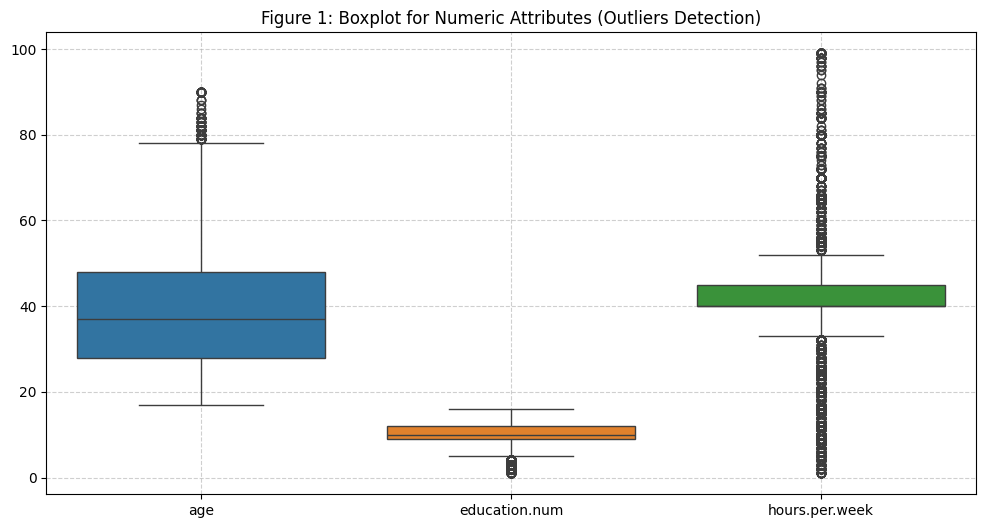

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['age', 'education.num', 'hours.per.week']])
plt.title('Figure 1: Boxplot for Numeric Attributes (Outliers Detection)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This boxplot visualizes the distribution and identifies potential outliers within three key numeric attributes. The plot clearly shows a significant number of outliers in the age and hours.per.week variables.

**Preprocessing Decision:** Outlier handling is necessary to prevent extreme values from distorting the decision boundaries of our classification models.

### **Histogram (Age Distribution)**

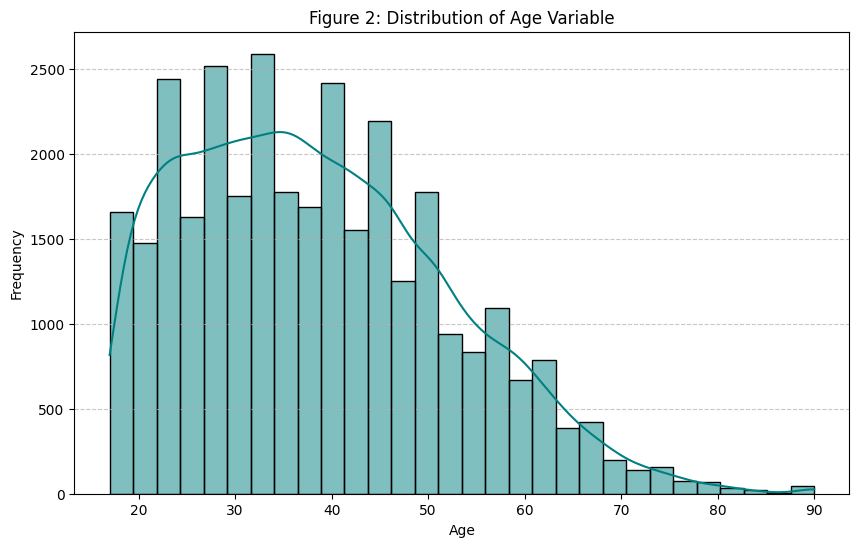

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=30, color='teal')
plt.title('Figure 2: Distribution of Age Variable')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The age distribution is right-skewed, meaning a larger portion of the population consists of younger individuals (aged 20–45).

### **Bar Plot (Income Distribution)**

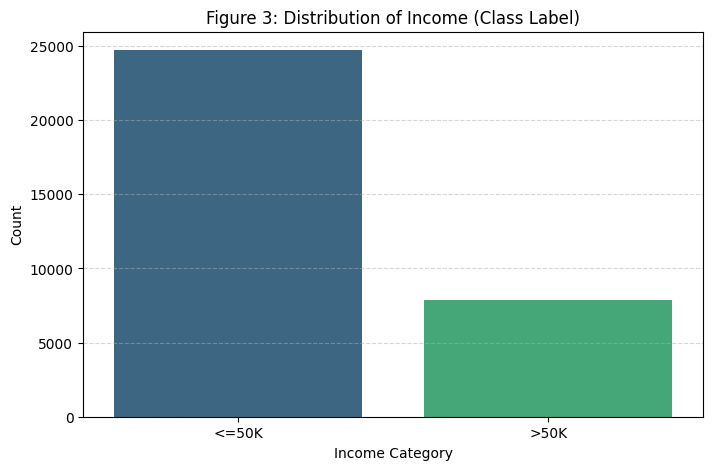

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='income', data=df, hue='income', palette='viridis', legend=False)
plt.title('Figure 3: Distribution of Income (Class Label)')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

The chart shows a clear disparity in the classes within the dataset. The number of individuals earning ≤ 50,000
is much larger than those earning > 50,000.

This result is very important — we should use evaluation metrics beyond simple accuracy, such as the confusion matrix, to ensure that the model is not biased toward the larger class.

## **Part 2: Data Preprocessing**

In [14]:
# Creating a copy of the raw dataset
df_preprocessed = df.copy()
# Snapshot of the raw dataset as required
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### **Task 1: Data Cleaning (Handling Missing Values)**

In [15]:
# We drop rows with missing values
df_preprocessed.dropna(inplace=True)

print(f"Total records in Raw Data: {len(df)}")
print(f"Total records after Cleaning: {len(df_preprocessed)}")
print("\nSnapshot of the Preprocessed Data (After Task 1):")
df_preprocessed.head()

Total records in Raw Data: 32561
Total records after Cleaning: 30162

Snapshot of the Preprocessed Data (After Task 1):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


**Why:** Our analysis showed missing values in workclass (1,836), occupation (1,843), and native.country (583). We used `dropna()` to remove incomplete records.

**Improvement:** Removing incomplete records (noise) leads to more reliable classification results.

**Attributes involved:** workclass, occupation, and native.country.

### **Task 2: Variable Transformation (Label Encoding)**

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['workclass', 'education', 'marital.status', 'occupation',
                       'relationship', 'race', 'sex', 'native.country', 'income']

for col in categorical_columns:
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])

print("Snapshot of the Preprocessed Data (After Label Encoding):")
df_preprocessed.head()

Snapshot of the Preprocessed Data (After Label Encoding):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


**Why:** Machine learning algorithms including Decision Tree require numerical input. We used `LabelEncoder` from sklearn to map each unique category to an integer.

**Improvement:** Makes nominal and ordinal data compatible with data mining algorithms.

**Attributes involved:** workclass, education, marital.status, occupation, relationship, race, sex, native.country, and income.

### **Task 3: Feature Scaling (Normalization)**

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

df_preprocessed[numeric_features] = scaler.fit_transform(df_preprocessed[numeric_features])

print("Final Preprocessed Data Snapshot (After Scaling):")
df_preprocessed.head()

Final Preprocessed Data Snapshot (After Scaling):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,3.316630,2,-0.538790,11,-0.439738,6,3,1,4,0,-0.147445,10.555814,-1.914161,38,0
3,1.184831,2,-0.467906,5,-2.400559,0,6,4,4,0,-0.147445,9.427915,-0.077734,38,0
4,0.195067,2,0.708645,15,-0.047574,5,9,3,4,0,-0.147445,9.427915,-0.077734,38,0
5,-0.337883,2,0.256222,11,-0.439738,0,7,4,4,0,-0.147445,9.106365,0.339636,38,0
6,-0.033340,2,-0.370964,0,-1.616231,5,0,4,4,1,-0.147445,9.106365,-0.077734,38,0


**Why:** Numeric attributes have very different scales (e.g., capital.gain vs age). We applied `StandardScaler` to ensure each feature contributes equally.

**Improvement:** Prevents large-range attributes from dominating distance-based calculations in K-Means and helps Decision Tree find better split points.

**Attributes involved:** age, fnlwgt, education.num, capital.gain, capital.loss, and hours.per.week.

In [18]:
df_preprocessed.to_csv('Preprocessed_dataset.csv', index=False)

print("Preprocessed Dataset Snapshot:")
df_preprocessed.head()

Preprocessed Dataset Snapshot:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,3.316630,2,-0.538790,11,-0.439738,6,3,1,4,0,-0.147445,10.555814,-1.914161,38,0
3,1.184831,2,-0.467906,5,-2.400559,0,6,4,4,0,-0.147445,9.427915,-0.077734,38,0
4,0.195067,2,0.708645,15,-0.047574,5,9,3,4,0,-0.147445,9.427915,-0.077734,38,0
5,-0.337883,2,0.256222,11,-0.439738,0,7,4,4,0,-0.147445,9.106365,0.339636,38,0
6,-0.033340,2,-0.370964,0,-1.616231,5,0,4,4,1,-0.147445,9.106365,-0.077734,38,0


# **5. Data Mining Technique**

## Classification — Decision Tree

We use `DecisionTreeClassifier` from `sklearn.tree` with:
- **Two attribute selection measures:** Entropy (Information Gain) and Gini Index
- **Three train/test partitions:** 90/10, 80/20, 70/30
- `random_state=1` for reproducible results

## Clustering — K-Means

We use `KMeans` from `sklearn.cluster` with:
- **Three values of K:** 2, 3, and 5
- `random_state=42` for reproducibility
- Evaluation: **Silhouette Score** (via yellowbrick) and **WCSS (Elbow Method)**

# **6. Evaluation and Comparison**

## **Part 1: Classification using Decision Tree**

### Importing Required Libraries

In [19]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### Loading the Preprocessed Data

In [20]:
# Load data
df = pd.read_csv("Preprocessed_dataset.csv")
print(df.head())

        age  workclass    fnlwgt  education  education.num  marital.status  \
0  3.316630          2 -0.538790         11      -0.439738               6   
1  1.184831          2 -0.467906          5      -2.400559               0   
2  0.195067          2  0.708645         15      -0.047574               5   
3 -0.337883          2  0.256222         11      -0.439738               0   
4 -0.033340          2 -0.370964          0      -1.616231               5   

   occupation  relationship  race  sex  capital.gain  capital.loss  \
0           3             1     4    0     -0.147445     10.555814   
1           6             4     4    0     -0.147445      9.427915   
2           9             3     4    0     -0.147445      9.427915   
3           7             4     4    0     -0.147445      9.106365   
4           0             4     4    1     -0.147445      9.106365   

   hours.per.week  native.country  income  
0       -1.914161              38       0  
1       -0.077734     

### Feature Selection

In [21]:
# Split dataset in features and target variable
fn = df.keys().tolist()[:-1]  # df columns names without last column 'income'
X = df[fn]  # Features
y = df['income']  # Target variable

### Building and Evaluating Models — Entropy (Information Gain)

#### 90% Training / 10% Testing

Accuracy: 0.8100762346702022
[[1978  294]
 [ 279  466]]
Precision   : 0.6132
Sensitivity : 0.6255
Specificity : 0.8706


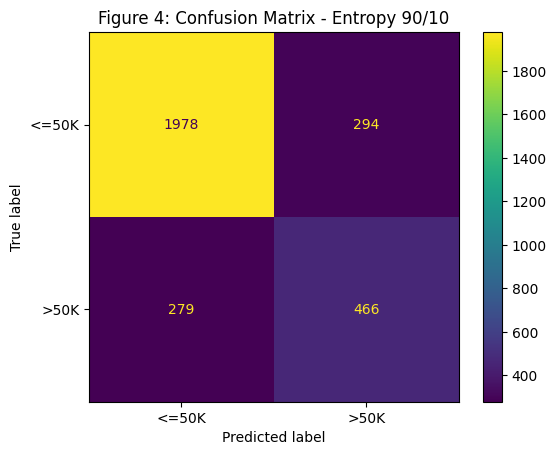

In [22]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

# Create Decision Tree classifier object
clf_e_9010 = DecisionTreeClassifier(criterion="entropy")
# Train Decision Tree Classifier
clf_e_9010 = clf_e_9010.fit(X_train, y_train)
# Predict the response for test dataset
y_pred = clf_e_9010.predict(X_test)

# Model Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
cn = df['income'].unique()
disp = ConfusionMatrixDisplay.from_estimator(clf_e_9010, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 4: Confusion Matrix - Entropy 90/10')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')

plt.show()

#### 80% Training / 20% Testing

Accuracy: 0.8112050389524283
[[3921  594]
 [ 545  973]]
Precision   : 0.6209
Sensitivity : 0.6410
Specificity : 0.8684


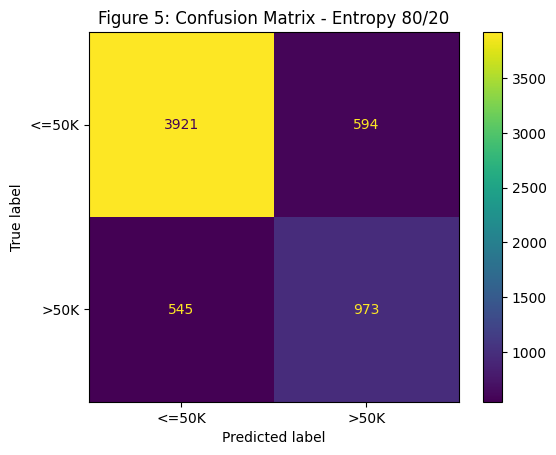

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

clf_e_8020 = DecisionTreeClassifier(criterion="entropy")
clf_e_8020 = clf_e_8020.fit(X_train, y_train)
y_pred = clf_e_8020.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(clf_e_8020, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 5: Confusion Matrix - Entropy 80/20')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')
plt.show()

#### 70% Training / 30% Testing

Accuracy: 0.8118024091059786
[[5882  899]
 [ 804 1464]]
Precision   : 0.6196
Sensitivity : 0.6455
Specificity : 0.8674


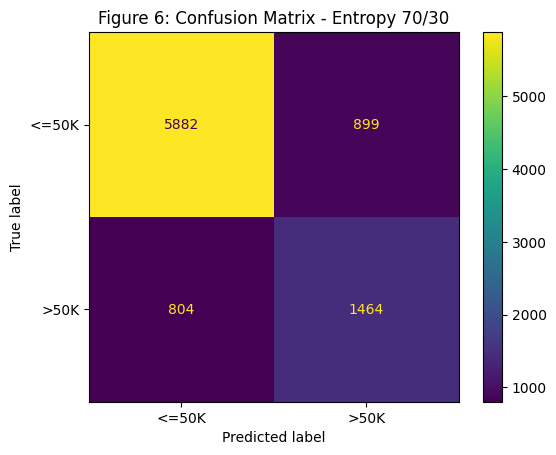

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf_e_7030 = DecisionTreeClassifier(criterion="entropy")
clf_e_7030 = clf_e_7030.fit(X_train, y_train)
y_pred = clf_e_7030.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(clf_e_7030, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 6: Confusion Matrix - Entropy 70/30')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')

plt.show()

### Building and Evaluating Models — Gini Index

#### 90% Training / 10% Testing

Accuracy: 0.8064302287040106
[[1960  312]
 [ 272  473]]
Precision   : 0.6025
Sensitivity : 0.6349
Specificity : 0.8627


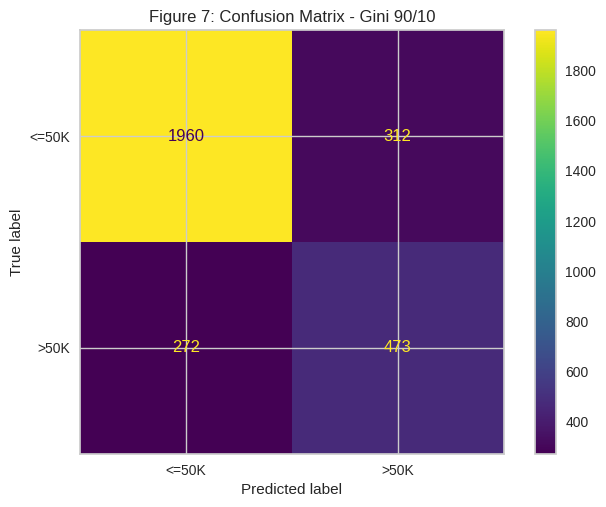

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

# Create Decision Tree classifier object (default is Gini)
clf_g_9010 = DecisionTreeClassifier()
clf_g_9010 = clf_g_9010.fit(X_train, y_train)
y_pred = clf_g_9010.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(clf_g_9010, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 7: Confusion Matrix - Gini 90/10')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')
plt.show()

#### 80% Training / 20% Testing

Accuracy: 0.811868059008785
[[3954  561]
 [ 574  944]]
Precision   : 0.6272
Sensitivity : 0.6219
Specificity : 0.8757


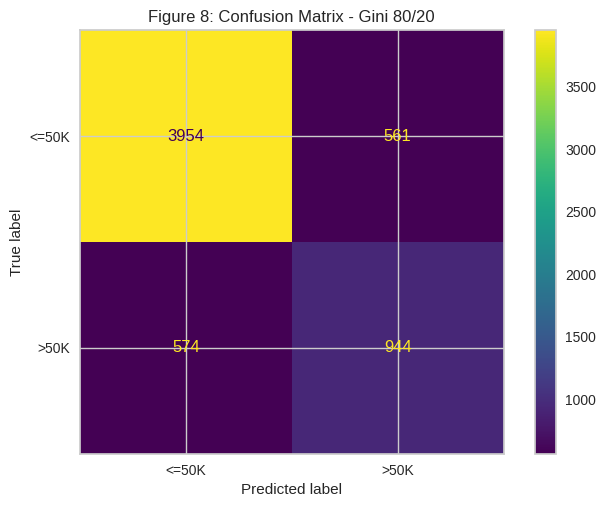

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

clf_g_8020 = DecisionTreeClassifier()
clf_g_8020 = clf_g_8020.fit(X_train, y_train)
y_pred = clf_g_8020.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(clf_g_8020, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 8: Confusion Matrix - Gini 80/20')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')
plt.show()

#### 70% Training / 30% Testing

Accuracy: 0.8098132390319372
[[5889  892]
 [ 829 1439]]
Precision   : 0.6173
Sensitivity : 0.6345
Specificity : 0.8685


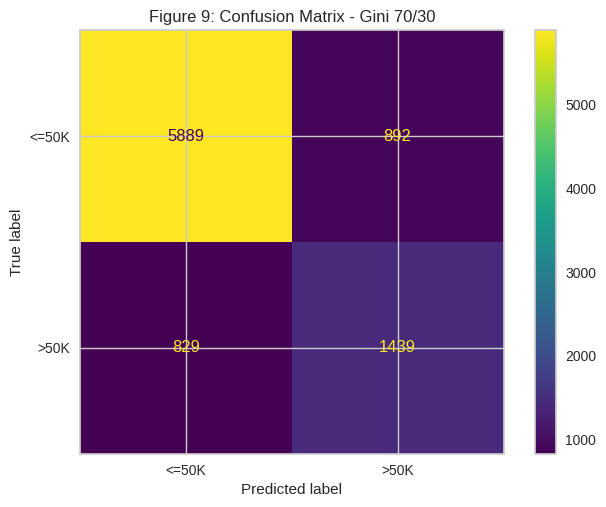

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf_g_7030 = DecisionTreeClassifier()
clf_g_7030 = clf_g_7030.fit(X_train, y_train)
y_pred = clf_g_7030.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(clf_g_7030, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title('Figure 9: Confusion Matrix - Gini 70/30')


tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f'Precision   : {precision:.4f}')
print(f'Sensitivity : {sensitivity:.4f}')
print(f'Specificity : {specificity:.4f}')

plt.show()

### Accuracy Comparison Table

| | 90% training / 10% testing | 80% training / 20% testing | 70% training / 30% testing |
|---|---|---|---|
| **Entropy (IG)** |81.14% |81.27% |81.03% |
| **Gini Index** |80.54% |81.20% |81.05% |



### Visualize Decision Tree

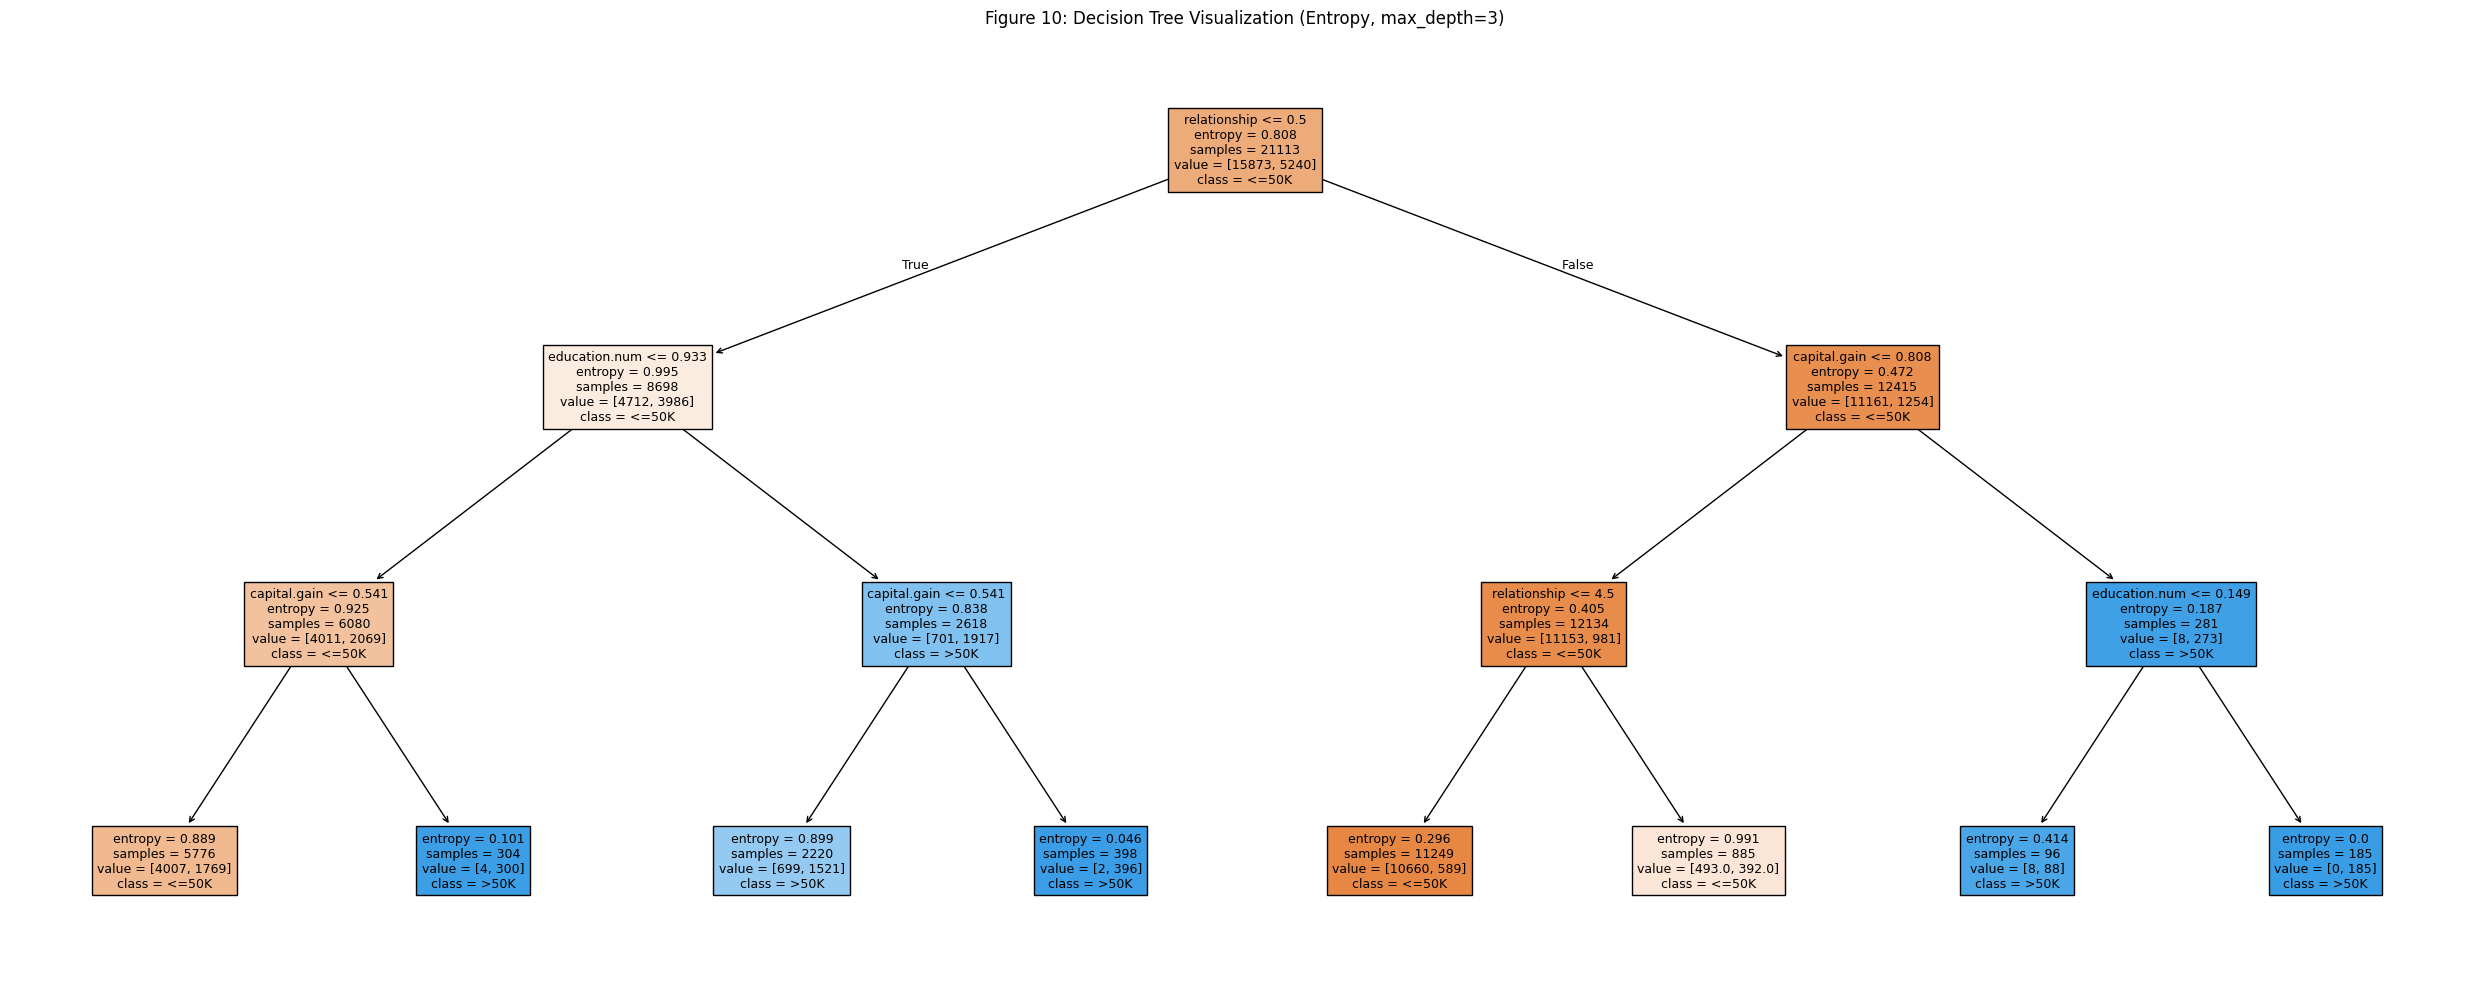

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
clf_viz = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf_viz.fit(X_train, y_train)

plt.figure(figsize=(25, 10))
plot_tree(clf_viz, feature_names=X.columns, class_names=['<=50K', '>50K'], filled=True, fontsize=9)
plt.title("Figure 10: Decision Tree Visualization (Entropy, max_depth=3)")
plt.tight_layout()
plt.show()

## **Part 2: Clustering using K-Means**

### Importing Required Libraries

In [29]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
%pip install yellowbrick
from yellowbrick.cluster import SilhouetteVisualizer

### Loading the Preprocessed Data

In [30]:
df = pd.read_csv("Preprocessed_dataset.csv")

# Extract features (excluding the target variable)
fn = df.keys().tolist()[:-1]
features = df[fn]

print("\nScaled DataFrame:")
print(features.head())


Scaled DataFrame:
        age  workclass    fnlwgt  education  education.num  marital.status  \
0  3.316630          2 -0.538790         11      -0.439738               6   
1  1.184831          2 -0.467906          5      -2.400559               0   
2  0.195067          2  0.708645         15      -0.047574               5   
3 -0.337883          2  0.256222         11      -0.439738               0   
4 -0.033340          2 -0.370964          0      -1.616231               5   

   occupation  relationship  race  sex  capital.gain  capital.loss  \
0           3             1     4    0     -0.147445     10.555814   
1           6             4     4    0     -0.147445      9.427915   
2           9             3     4    0     -0.147445      9.427915   
3           7             4     4    0     -0.147445      9.106365   
4           0             4     4    1     -0.147445      9.106365   

   hours.per.week  native.country  
0       -1.914161              38  
1       -0.077734  

### Elbow Method — Finding Optimal K

[2433417.7001193543, 1492600.1938904698, 1249873.0307786567, 911426.2201909062, 857924.5748254387, 711268.846961311, 685264.4582134595, 645330.2434107342, 626655.5274065746, 573736.3390491111]


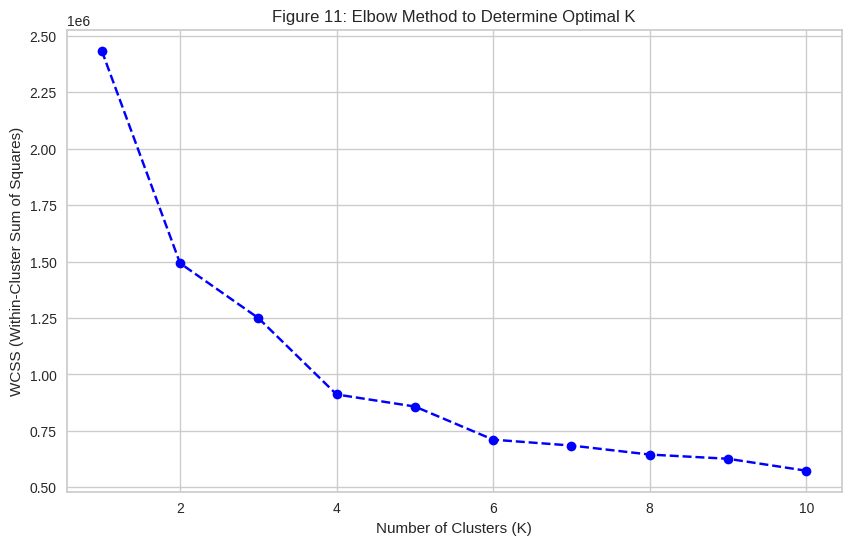

In [31]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)


print(wcss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='blue', linestyle='--')
plt.title('Figure 11: Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

### K = 2

In [32]:
np.random.seed(42)

# Run k-means clustering with 2 clusters
kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_result_2 = kmeans_2.fit(features)

print("Cluster Centers:")
print(kmeans_result_2.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result_2.labels_)

Cluster Centers:
[[-7.71141481e-02  2.16851107e+00  3.83843130e-01  8.82444668e+00
  -5.44880799e-01  2.76307847e+00  5.88128773e+00  1.43913481e+00
   3.38832998e+00  7.00201207e-01 -3.59150343e-02 -6.07671676e-02
  -2.39463203e-02  1.54255533e+01]
 [ 5.44129078e-03  2.20149783e+00 -2.70845511e-02  1.04402641e+01
   3.84476123e-02  2.56722510e+00  5.96539363e+00  1.41687371e+00
   3.69908426e+00  6.73954710e-01  2.53421908e-03  4.28782314e-03
   1.68968854e-03  3.78613260e+01]]

Cluster Labels:
[1 1 1 ... 1 1 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.6221834328790281


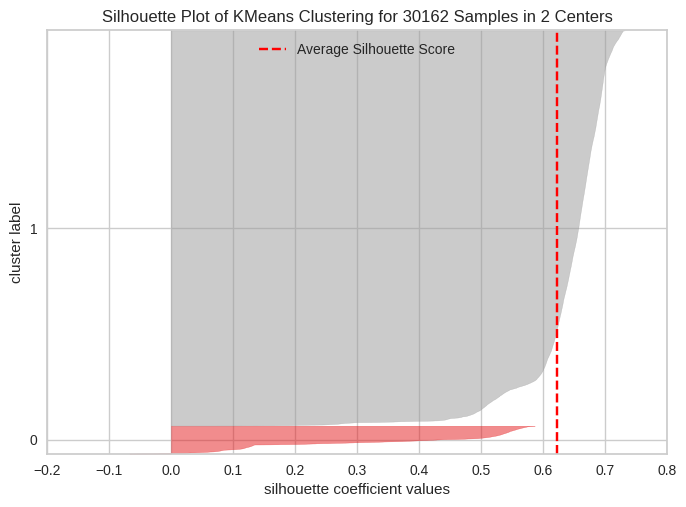

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 30162 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [33]:
# Silhouette visualization for K=2
visualizer_2 = SilhouetteVisualizer(kmeans_2, color="yellowbrick")
visualizer_2.fit(features)
print("The average silhouette score is:", visualizer_2.silhouette_score_)
visualizer_2.show()

### K = 3

In [34]:
np.random.seed(42)

kmeans_3 = KMeans(n_clusters=3, random_state=42)
kmeans_result_3 = kmeans_3.fit(features)

print("Cluster Centers:")
print(kmeans_result_3.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result_3.labels_)

Cluster Centers:
[[-2.22953573e-02  2.16724826e+00  8.36865246e-03  3.33150548e+00
  -1.06864750e+00  2.72607178e+00  6.16500499e+00  1.62961117e+00
   3.63609172e+00  6.69990030e-01 -9.80128260e-02 -5.48153070e-02
  -2.79240886e-01  3.78073280e+01]
 [ 9.86911079e-03  2.20717478e+00 -3.28581549e-02  1.16185866e+01
   2.21965776e-01  2.54100463e+00  5.93280371e+00  1.38178583e+00
   3.70957464e+00  6.74569679e-01  1.91882604e-02  1.42330181e-02
   4.82228542e-02  3.78673452e+01]
 [-7.52107446e-02  2.16851665e+00  3.83723942e-01  8.84106963e+00
  -5.43418326e-01  2.76185671e+00  5.87436932e+00  1.43642785e+00
   3.38698285e+00  7.00807265e-01 -3.55774069e-02 -6.25956462e-02
  -2.27727071e-02  1.53935419e+01]]

Cluster Labels:
[1 0 1 ... 1 1 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.2971919681190572


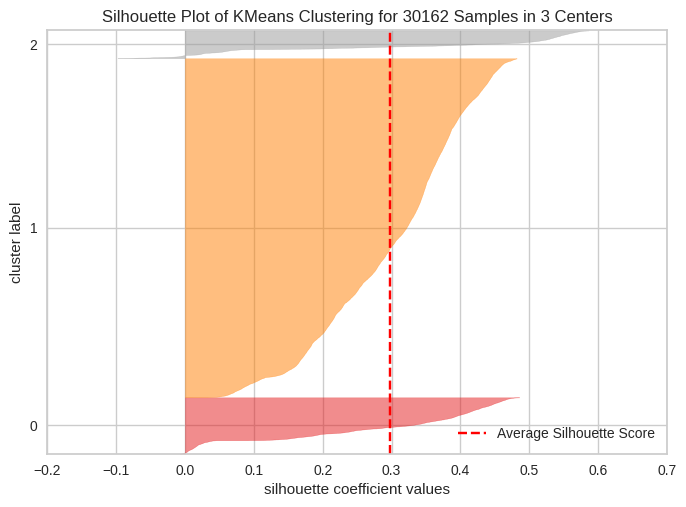

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 30162 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [35]:
visualizer_3 = SilhouetteVisualizer(kmeans_3, color="yellowbrick")
visualizer_3.fit(features)
print("The average silhouette score is:", visualizer_3.silhouette_score_)
visualizer_3.show()

### K = 5

In [36]:
np.random.seed(42)

kmeans_5 = KMeans(n_clusters=5, random_state=42)
kmeans_result_5 = kmeans_5.fit(features)

print("Cluster Centers:")
print(kmeans_result_5.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result_5.labels_)

Cluster Centers:
[[-4.64947057e-02  2.17586562e+00  1.66326522e-02  1.92800823e+00
  -1.59606450e+00  2.87315735e+00  6.08021940e+00  1.70791909e+00
   3.60815907e+00  6.82550566e-01 -1.09570399e-01 -7.33224548e-02
  -3.92657249e-01  3.75447377e+01]
 [-2.72178111e-01  2.13379883e+00 -2.26153642e-02  1.21745612e+01
  -1.33422404e-01  2.88733723e+00  6.53934705e+00  1.87752406e+00
   3.58331761e+00  6.04453671e-01 -1.07286239e-01 -1.01532744e-01
  -3.04731579e-01  3.78116626e+01]
 [-5.39128804e-02  2.17423057e+00  3.69293442e-01  9.02660407e+00
  -5.21771492e-01  2.75013041e+00  5.89827856e+00  1.42410016e+00
   3.37297861e+00  6.97443923e-01 -3.24129304e-02 -5.93438073e-02
  -1.81658474e-02  1.50594679e+01]
 [ 6.80845930e-02  2.21510601e+00 -1.92662150e-02  1.09601369e+01
   5.08540340e-01  2.49436837e+00  1.06026943e+01  1.16563604e+00
   3.75265018e+00  7.12124558e-01  9.21447387e-02  6.47048823e-02
   1.62299577e-01  3.78724602e+01]
 [ 9.70266820e-02  2.22856101e+00 -4.21160409e-02  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.20346527218746283


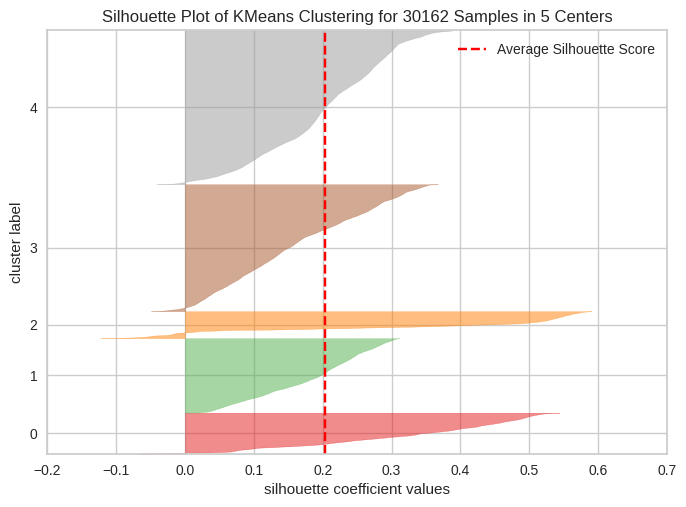

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 30162 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [37]:
visualizer_5 = SilhouetteVisualizer(kmeans_5, color="yellowbrick")
visualizer_5.fit(features)
print("The average silhouette score is:", visualizer_5.silhouette_score_)
visualizer_5.show()

### Clustering Evaluation Table

| | K=2 | K=3 | K=5 |
|---|---|---|---|
| **Average Silhouette Width** |0.6221 |0.2972 |0.2035 |
| **Total Within-Cluster Sum of Square (WCSS)** |1,492,600 |1,249,873 |911,426 |



### Cluster Visualization

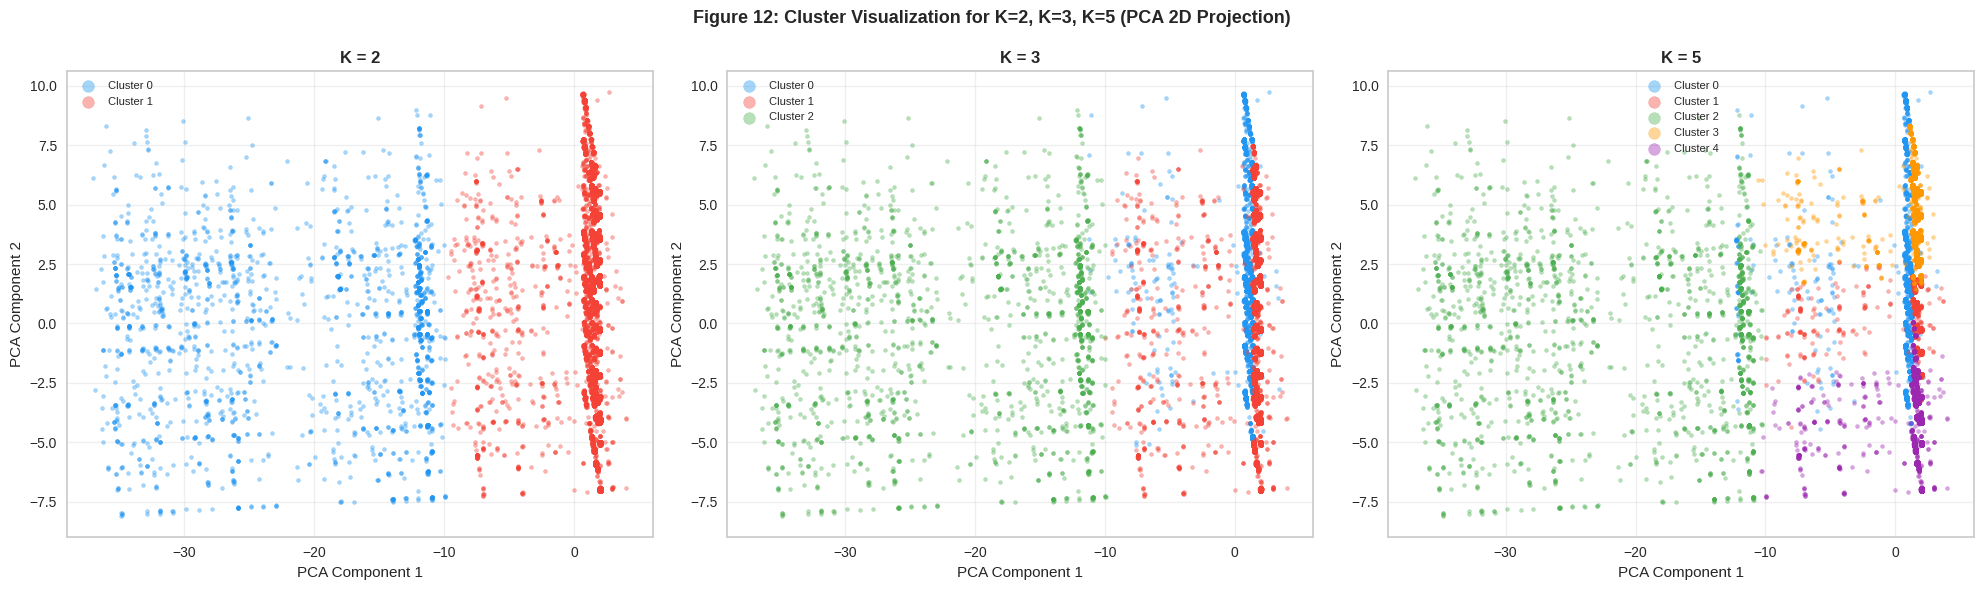

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(features)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 12: Cluster Visualization for K=2, K=3, K=5 (PCA 2D Projection)',
             fontsize=13, fontweight='bold')

colors_list = [
    ['#2196F3', '#F44336'],
    ['#2196F3', '#F44336', '#4CAF50'],
    ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
]

k_labels = [kmeans_result_2.labels_, kmeans_result_3.labels_, kmeans_result_5.labels_]

for ax, k, labels, colors in zip(axes, [2, 3, 5], k_labels, colors_list):
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[cluster_id], label=f'Cluster {cluster_id}',
                   alpha=0.4, s=8)
    ax.set_title(f'K = {k}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **7. Findings and Discussion**

##  Entropy (Information Gain)

In [53]:
data = {
    "Metrics": ["Accuracy", "Error Rate", "Sensitivity", "Specificity", "Precision"],
    "| 90%  / 10% |": ["0.8101", "0.1899", "0.6255", "0.8706", "0.6132"],
    "| 80%  / 20% |": ["0.8113", "0.1887", "0.6410", "0.8684", "0.6209"],
    "| 70%  / 30% |": ["0.8118", "0.1882", "0.6455", "0.8674", "0.6196"],
}
df_results = pd.DataFrame(data)
df_results.style.set_properties(**{"text-align": "center"})

,Metrics,| 90% / 10% |,| 80% / 20% |,| 70% / 30% |
0,Accuracy,0.8101,0.8113,0.8118
1,Error Rate,0.1899,0.1887,0.1882
2,Sensitivity,0.6255,0.6410,0.6455
3,Specificity,0.8706,0.8684,0.8674
4,Precision,0.6132,0.6209,0.6196


Based on the results presented for the models trained using different data splits, the following observations can be made:

**• Accuracy:**
Accuracy improves slightly as more training data is used, ranging from 81.01% to 81.18%. The 70–30 split achieves the highest accuracy (81.18%), followed by the 80–20 split (81.13%) and the 90–10 split (81.01%). This indicates that providing the model with more testing data slightly improves generalization performance.

**• Error Rate:**
The error rate ranges between 18.82% and 18.99%, which is the inverse of the accuracy results. The lowest error rate occurs in the 70–30 split (18.82%), showing that this configuration makes the fewest incorrect predictions.

**• Sensitivity (True Positive Rate):**
Sensitivity varies from 62.55% (90–10) to 64.55% (70–30). The 70–30 split provides the strongest ability to correctly detect income >50K cases (64.55%), followed by the 80–20 split (64.10%) and the 90–10 split (62.55%). Overall, the model's sensitivity improves as more test data is available.

**• Specificity (True Negative Rate):**
Specificity ranges from 86.74% to 87.06%. The highest value comes from the 90–10 split (87.06%), followed by the 80–20 split (86.84%) and the 70–30 split (86.74%). This means the model is most accurate at identifying income ≤50K cases under the 90–10 split.

**• Precision:**
Precision ranges from 61.32% to 62.09%, with the highest precision achieved in the 80–20 split (62.09%). This shows that the model produces fewer false positives with the 80–20 configuration.

**Conclusion:**
Overall, the Entropy model demonstrates reliable and consistent performance across all three splits. The 70–30 split delivers the highest accuracy (81.18%) and sensitivity (64.55%), while the 90–10 split achieves the highest specificity (87.06%). The 80–20 split offers a balanced performance across all metrics. Therefore, the best split depends on the goal: use 70–30 for maximum sensitivity, and 90–10 for maximum specificity.

##  Gini Index

In [55]:
data = {
    "Metrics": ["Accuracy", "Error Rate", "Sensitivity", "Specificity", "Precision"],
    "| 90%  / 10% |": ["0.8064", "0.1936", "0.6349", "0.8627", "0.6025"],
    "| 80%  / 20% |": ["0.8119", "0.1881", "0.6219", "0.8857", "0.6272"],
    "| 70%  / 30% |": ["0.8098", "0.1902", "0.6345", "0.8685", "0.6173"],
}
df_results2 = pd.DataFrame(data)
df_results2.style.set_properties(**{"text-align": "center"})

,Metrics,| 90% / 10% |,| 80% / 20% |,| 70% / 30% |
0,Accuracy,0.8064,0.8119,0.8098
1,Error Rate,0.1936,0.1881,0.1902
2,Sensitivity,0.6349,0.6219,0.6345
3,Specificity,0.8627,0.8857,0.8685
4,Precision,0.6025,0.6272,0.6173


Based on the results presented for the models trained using different data splits, the following observations can be made:

**• Accuracy:**
Accuracy values range from 80.64% to 81.19%, showing that the Gini model performs consistently across different splits. The 80–20 split achieves the highest accuracy (81.19%), followed by the 70–30 split (80.98%), while the 90–10 split records the lowest (80.64%). This indicates that the model learns more effectively when given more training data.

**• Error Rate:**
The error rate lies between 18.81% and 19.36%. The lowest error rate occurs in the 80–20 split (18.81%), confirming that this configuration produces the fewest incorrect predictions.

**• Sensitivity (True Positive Rate):**
Sensitivity ranges from 62.19% (80–20) to 63.49% (90–10). The 90–10 split achieves the highest sensitivity (63.49%), closely followed by the 70–30 split (63.45%), while the 80–20 split shows a slight drop to 62.19%.

**• Specificity (True Negative Rate):**
Specificity values range between 86.27% and 88.57%, with the highest value from the 80–20 split (88.57%). This means the model is strongest at identifying income ≤50K cases under the 80–20 split, with fewer false positives.

**• Precision:**
Precision ranges from 60.25% to 62.72%, with the highest precision seen in the 80–20 split (62.72%). This means most of the model's positive predictions were correct under the 80–20 configuration.

**Conclusion:**
The Gini Index model shows strong performance across all three splits, with the 80–20 split producing the best results in accuracy (81.19%), error rate (18.81%), specificity (88.57%), and precision (62.72%). The 90–10 split achieves the highest sensitivity (63.49%). Overall, the Gini-based decision tree provides stable results, with performance consistently benefiting from balanced train-test splits.

## The Best Model Between Information Gain and Gini Index

In [56]:
data = {
    " ": ["Accuracy", "Error Rate", "Sensitivity", "Specificity", "Precision"],
    "Entropy (IG)": ["0.8113", "0.1887", "0.6410", "0.8684", "0.6209"],
    "Gini Index":  ["0.8119", "0.1881", "0.6219", "0.8857", "0.6272"],
}
df_best = pd.DataFrame(data)
df_best.style.set_properties(**{"text-align": "center"})

,,Entropy (IG),Gini Index
0,Accuracy,0.8113,0.8119
1,Error Rate,0.1887,0.1881
2,Sensitivity,0.6410,0.6219
3,Specificity,0.8684,0.8857
4,Precision,0.6209,0.6272


**Accuracy and Error Rate:**
The Gini Index achieves a slightly higher accuracy of 81.19%, compared to Entropy's 81.13%. Both methods perform similarly, but Gini has a marginally lower error rate — 18.81% versus 18.87% for Entropy. This means Gini makes slightly fewer mistakes overall, making it a bit more reliable for predicting income levels.

**Sensitivity and Specificity:**
With the 80/20 split, Entropy shows higher sensitivity at 64.10%, compared to the Gini Index at 62.19%, meaning Entropy is better at correctly identifying income >50K cases. On the other hand, the Gini Index achieves significantly higher specificity at 88.57%, while Entropy records 86.84%, showing that Gini is more accurate at recognizing income ≤50K cases. Overall, Entropy is stronger at catching positive cases, while Gini performs better at ruling out negative ones.

**Precision:**
The Gini Index achieves a precision of 62.72%, slightly higher than Entropy's 62.09%. This small advantage means the Gini-based model produces fewer false positives, making it a bit more reliable when predicting true positive cases.

Conclusion:
Both splitting criteria perform well, but each excels in different areas. Entropy (IG) achieves stronger sensitivity (64.10%), making it the better option when correctly identifying income >50K cases is the priority. In contrast, the Gini Index offers higher accuracy (81.19%), specificity (88.57%), and precision (62.72%), making it more dependable for avoiding false positives and correctly identifying income ≤50K cases. The optimal choice ultimately depends on the goal; Entropy is preferred when maximizing true-positive detection is most important, while Gini is preferred when reducing false positives matters more.

# **8. References**

[1] N. Chakrabarty and S. Biswas, "A Statistical Approach to Adult Census Income Level Prediction," in 2018 International Conference on Advances in Computing, Communication Control and Networking (ICACCCN), IEEE, 2018, pp. 207–212. doi: 10.1109/icacccn.2018.8748528. [Online]. Available: https://ieeexplore.ieee.org/abstract/document/8748528